# Paper-Aligned PCA — Column-Standardized

This is a standalone mirror of `02_replicate_paper.ipynb`. The **only** methodological
change is the scaling step.

**The fix.** The original notebook called `sklearn.preprocessing.normalize(X)`, which L2-normalizes
**each row (utterance) to unit length** — it does not put the *features* on a common scale. Because
the 11 features span ~5 orders of magnitude in variance (token_count var ≈ 163, loudness var ≈ 0.00007),
row-normalization let one feature dominate PC0 for reasons of scale, not conversational structure.

Here we instead **standardize each column** (z-score → PCA on the *correlation* matrix), which is the
textbook choice for PCA on mixed-unit features (counts, seconds, per-second rates, normalized loudness).

We run **two scalers** so we can see how much the heavy turn-gap outliers / zero-inflated rate features
distort things:
- **StandardScaler** — z-score (mean 0, std 1). The clean, faithful comparison.
- **RobustScaler** — centers on the median and scales by the IQR; far less sensitive to the
  Turn Gap outliers (−24.8 to +66 s) and zero-inflation.

Reference points to compare PC0 explained variance against: **57.83%** (original row-normalized
notebook) and **65.91%** (the paper).

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

## Step 1 — Load

In [2]:
df = pd.read_csv("../utterances_v2/merge_test.csv")
print(f"Shape: {df.shape}")

Shape: (214204, 39)


## Step 2 — Paper-Aligned Feature Columns (Table 1 minus pitch)

Same 11 columns as the original paper-aligned notebook.

In [3]:
feature_cols = [
    "token_count",
    "loudness mean",
    "loudness std",
    "loudness range",
    "Turn Gap",
    "word_rate",
    "syllable_rate",
    "Pronouns per Second",
    "Repetitions In Current Utterance",
    "Repetitions In Previous Utterance",
    "Filler Words per Second",
]
print(f"Feature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  {c}")

Feature columns (11):
  token_count
  loudness mean
  loudness std
  loudness range
  Turn Gap
  word_rate
  syllable_rate
  Pronouns per Second
  Repetitions In Current Utterance
  Repetitions In Previous Utterance
  Filler Words per Second


## Step 3 — Clean (same inf/NaN drop as original, keeps row counts comparable)

In [4]:
before = len(df)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Rows before: {before}, after: {len(df)}, dropped: {before - len(df)}")
X = df[feature_cols].values

Rows before: 214204, after: 212210, dropped: 1994


## Step 4 — Helper functions

Each scaler runs the identical downstream analysis (PCA → histogram/scree → loadings →
silhouette/BIC → GMM overlay), so StandardScaler and RobustScaler are directly comparable.

In [5]:
def run_pca(X, scaler):
    """Scale columns with the given scaler, then PCA across all components."""
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=X.shape[1])
    scores = pca.fit_transform(X_scaled)
    return X_scaled, pca, scores

def report_variance(pca, name):
    print(f"[{name}] explained variance ratio:")
    print(pca.explained_variance_ratio_)
    print(f"[{name}] cumulative:")
    print(np.cumsum(pca.explained_variance_ratio_))
    print(f"[{name}] PC0 explains {pca.explained_variance_ratio_[0]*100:.2f}% of variance")

def plot_hist_scree(scores, pca, name):
    n = pca.n_components_
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.histplot(scores[:, 0], bins=200, ax=axes[0])
    axes[0].set_title(f"Histogram of PC0 - {name}")
    axes[0].set_xlabel("pca0")
    axes[1].bar(range(n), pca.explained_variance_ratio_)
    axes[1].set_title(f"Explained Variance Ratio - {name}")
    axes[1].set_xlabel("Component"); axes[1].set_ylabel("Variance Ratio")
    axes[1].set_xticks(range(n))
    plt.tight_layout(); plt.show()

def loadings_table(pca, feature_cols, name):
    t = pd.DataFrame({"Feature": feature_cols, "Magnitude": pca.components_[0]})
    t = (t.assign(_abs=t["Magnitude"].abs())
           .sort_values("_abs", ascending=False)
           .drop(columns="_abs").reset_index(drop=True))
    disp = t.copy()
    disp["Magnitude"] = disp["Magnitude"].apply(lambda x: f"{x:+.4f}")
    print(f"Table 2 - feature importance to PC0 ({name})\n")
    print(disp[["Magnitude", "Feature"]].to_string(index=False))
    return t

def silhouette_bic(pc0):
    X1 = pc0.reshape(-1, 1)
    ks = list(range(2, 11))
    sil = []
    for k in ks:
        g = GaussianMixture(n_components=k, random_state=0).fit(X1)
        sil.append(silhouette_score(X1, g.predict(X1), sample_size=10000, random_state=0))
    best_k = ks[int(np.argmax(sil))]
    bics = [GaussianMixture(n_components=k, random_state=0).fit(X1).bic(X1) for k in range(1, 11)]
    best_k_bic = int(np.argmin(bics)) + 1
    return ks, sil, best_k, bics, best_k_bic

def fit_gmm_overlay(pc0, ks, sil, best_k, name):
    X1 = pc0.reshape(-1, 1)
    g = GaussianMixture(n_components=best_k, random_state=0).fit(X1)
    means = g.means_.flatten(); stds = np.sqrt(g.covariances_.flatten()); weights = g.weights_
    print(f"[{name}] GMM k={best_k}:")
    for i in np.argsort(means):
        print(f"  component {i}: mean={means[i]:+.4f}, std={stds[i]:.4f}, weight={weights[i]:.3f}")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(ks, sil, "o-")
    axes[0].axvline(best_k, color="red", ls="--", alpha=0.5, label=f"best k={best_k}")
    axes[0].set_xlabel("k"); axes[0].set_ylabel("Silhouette")
    axes[0].set_title(f"Silhouette vs k - {name}"); axes[0].legend()
    sns.histplot(pc0, bins=200, stat="density", ax=axes[1], alpha=0.5)
    xs = np.linspace(pc0.min(), pc0.max(), 1000); total = np.zeros_like(xs)
    for i in range(best_k):
        comp = weights[i]*(1/(stds[i]*np.sqrt(2*np.pi)))*np.exp(-0.5*((xs-means[i])/stds[i])**2)
        axes[1].plot(xs, comp, label=f"component {i} (mean={means[i]:+.3f})"); total += comp
    axes[1].plot(xs, total, "k--", label="total mixture")
    axes[1].set_xlabel("pca0"); axes[1].set_title(f"PC0 + GMM(k={best_k}) - {name}"); axes[1].legend()
    plt.tight_layout(); plt.show()
    return g

# Part A — StandardScaler (z-score per column)

This is the primary result: the direct, faithful replacement of row-normalization with column
standardization.

### A1 — Standardize columns & PCA

In [6]:
X_std, pca_std, scores_std = run_pca(X, StandardScaler())
report_variance(pca_std, "StandardScaler")

[StandardScaler] explained variance ratio:
[0.43890905 0.19348563 0.09709898 0.0811662  0.0754758  0.0570886
 0.03150044 0.01104308 0.00851703 0.00353613 0.00217907]
[StandardScaler] cumulative:
[0.43890905 0.63239468 0.72949366 0.81065986 0.88613566 0.94322426
 0.97472469 0.98576777 0.99428479 0.99782093 1.        ]
[StandardScaler] PC0 explains 43.89% of variance


### A2 — Histogram of PC0 & scree

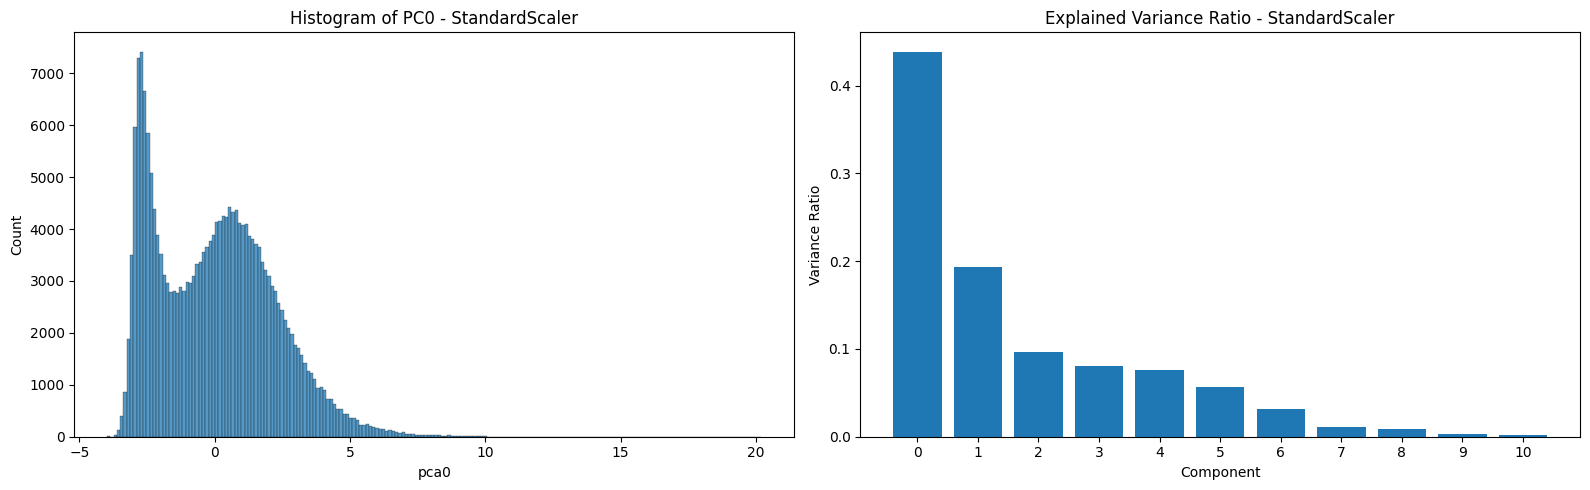

In [7]:
plot_hist_scree(scores_std, pca_std, "StandardScaler")

### A3 — Table 2: feature importance to PC0

Compare ordering against the paper's Table 2 (top: Turn gap -0.7755, Token count -0.5935,
Self-repetitions -0.2039). PCA sign is arbitrary, so the overall sign may flip.

In [8]:
load_std = loadings_table(pca_std, feature_cols, "StandardScaler")

Table 2 - feature importance to PC0 (StandardScaler)

Magnitude                           Feature
  +0.3947                         word_rate
  +0.3856                     syllable_rate
  +0.3826                       token_count
  +0.3248               Pronouns per Second
  +0.3179                     loudness mean
  +0.3113                    loudness range
  +0.3014  Repetitions In Current Utterance
  +0.2743                      loudness std
  +0.2001 Repetitions In Previous Utterance
  +0.1462           Filler Words per Second
  +0.1347                          Turn Gap


### A4 — Silhouette (k=2..10) & BIC (k=1..10)

In [9]:
ks, sil_std, bestk_std, bics_std, bestk_bic_std = silhouette_bic(scores_std[:, 0])
for k, s in zip(ks, sil_std):
    print(f"k={k}: silhouette = {s:.4f}")
print(f"\nBest k by silhouette: {bestk_std}")
print(f"\n{'k':>3} {'BIC':>14}")
print("-" * 20)
for k, b in zip(range(1, 11), bics_std):
    print(f"{k:>3} {b:>14.0f}")
print(f"\nBest k by BIC: {bestk_bic_std}")

k=2: silhouette = 0.4905
k=3: silhouette = 0.5246
k=4: silhouette = 0.5603
k=5: silhouette = 0.5693
k=6: silhouette = 0.5645
k=7: silhouette = 0.5566
k=8: silhouette = 0.5384
k=9: silhouette = 0.5350
k=10: silhouette = 0.5324

Best k by silhouette: 5

  k            BIC
--------------------
  1         936361
  2         882908
  3         878066
  4         877647
  5         876724
  6         875547
  7         874866
  8         873857
  9         873620
 10         873581

Best k by BIC: 10


### A5 — Best-k GMM fit & overlay

[StandardScaler] GMM k=5:
  component 3: mean=-2.5615, std=0.3982, weight=0.277
  component 1: mean=-0.8727, std=0.6683, weight=0.215
  component 4: mean=+0.7045, std=0.6299, weight=0.248
  component 0: mean=+2.2660, std=0.7991, weight=0.185
  component 2: mean=+4.0443, std=1.5973, weight=0.075


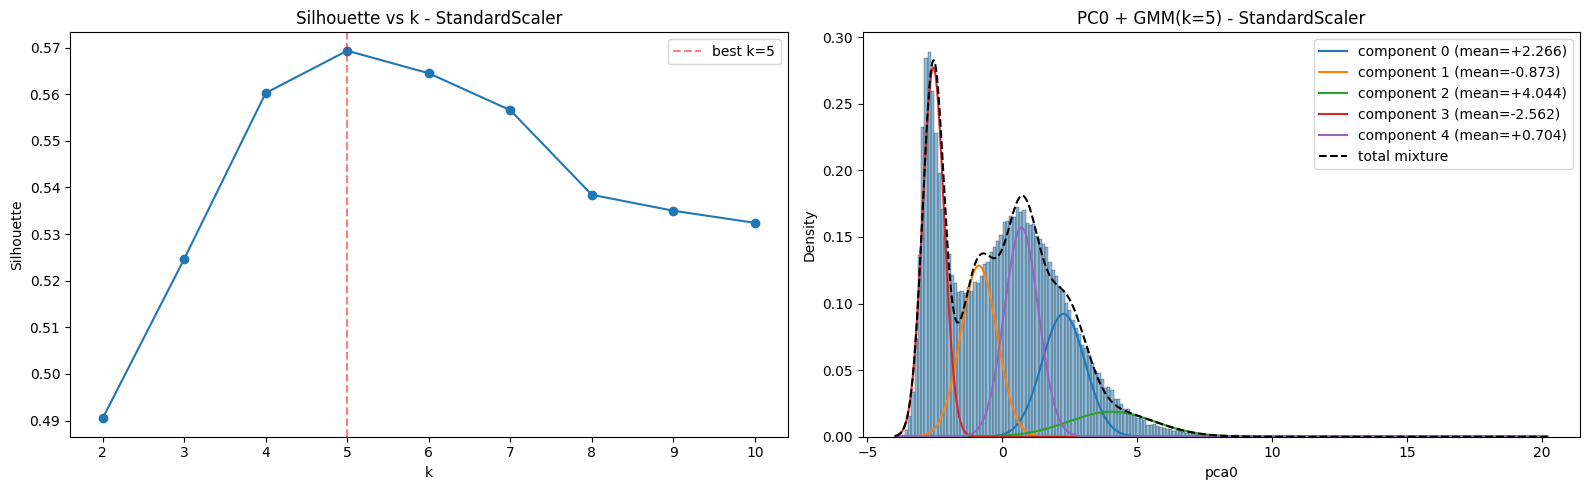

In [10]:
gmm_std = fit_gmm_overlay(scores_std[:, 0], ks, sil_std, bestk_std, "StandardScaler")

# Part B — RobustScaler (median / IQR per column)

Same pipeline, but centering on the median and scaling by the IQR. If Part A's PC0 looks driven by
the Turn Gap outliers or zero-inflated rate features, this version should look meaningfully different.

### B1 — Robust-scale columns & PCA

In [11]:
X_rob, pca_rob, scores_rob = run_pca(X, RobustScaler())
report_variance(pca_rob, "RobustScaler")

[RobustScaler] explained variance ratio:
[6.24717033e-01 1.59288213e-01 1.00419900e-01 6.72553018e-02
 2.27004634e-02 1.55690222e-02 4.36063949e-03 2.93182271e-03
 1.72190491e-03 6.62946175e-04 3.72753350e-04]
[RobustScaler] cumulative:
[0.62471703 0.78400525 0.88442515 0.95168045 0.97438091 0.98994993
 0.99431057 0.9972424  0.9989643  0.99962725 1.        ]
[RobustScaler] PC0 explains 62.47% of variance


### B2 — Histogram of PC0 & scree

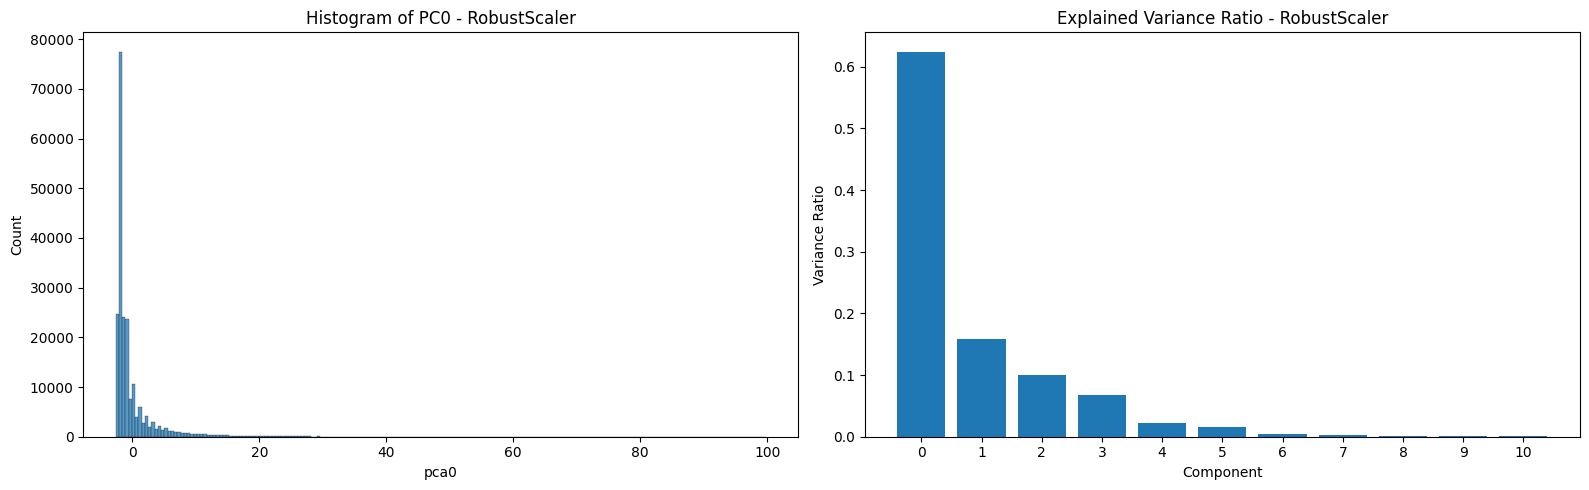

In [12]:
plot_hist_scree(scores_rob, pca_rob, "RobustScaler")

### B3 — Table 2: feature importance to PC0

In [13]:
load_rob = loadings_table(pca_rob, feature_cols, "RobustScaler")

Table 2 - feature importance to PC0 (RobustScaler)

Magnitude                           Feature
  +0.9686 Repetitions In Previous Utterance
  +0.2063  Repetitions In Current Utterance
  +0.0798                       token_count
  +0.0490                     syllable_rate
  +0.0482                         word_rate
  +0.0438                    loudness range
  +0.0431                     loudness mean
  +0.0378               Pronouns per Second
  +0.0369                          Turn Gap
  +0.0303                      loudness std
  +0.0245           Filler Words per Second


### B4 — Silhouette (k=2..10) & BIC (k=1..10)

In [14]:
ks, sil_rob, bestk_rob, bics_rob, bestk_bic_rob = silhouette_bic(scores_rob[:, 0])
for k, s in zip(ks, sil_rob):
    print(f"k={k}: silhouette = {s:.4f}")
print(f"\nBest k by silhouette: {bestk_rob}")
print(f"\n{'k':>3} {'BIC':>14}")
print("-" * 20)
for k, b in zip(range(1, 11), bics_rob):
    print(f"{k:>3} {b:>14.0f}")
print(f"\nBest k by BIC: {bestk_bic_rob}")

k=2: silhouette = 0.6524
k=3: silhouette = 0.6169
k=4: silhouette = 0.5707
k=5: silhouette = 0.5832
k=6: silhouette = 0.5892
k=7: silhouette = 0.5996
k=8: silhouette = 0.5982
k=9: silhouette = 0.6040
k=10: silhouette = 0.6051

Best k by silhouette: 2

  k            BIC
--------------------
  1        1229528
  2         833177
  3         767578
  4         712188
  5         705468
  6         703777
  7         702533
  8         701941
  9         700474
 10         700202

Best k by BIC: 10


### B5 — Best-k GMM fit & overlay

[RobustScaler] GMM k=2:
  component 0: mean=-1.6622, std=0.5526, weight=0.722
  component 1: mean=+4.3137, std=6.5212, weight=0.278


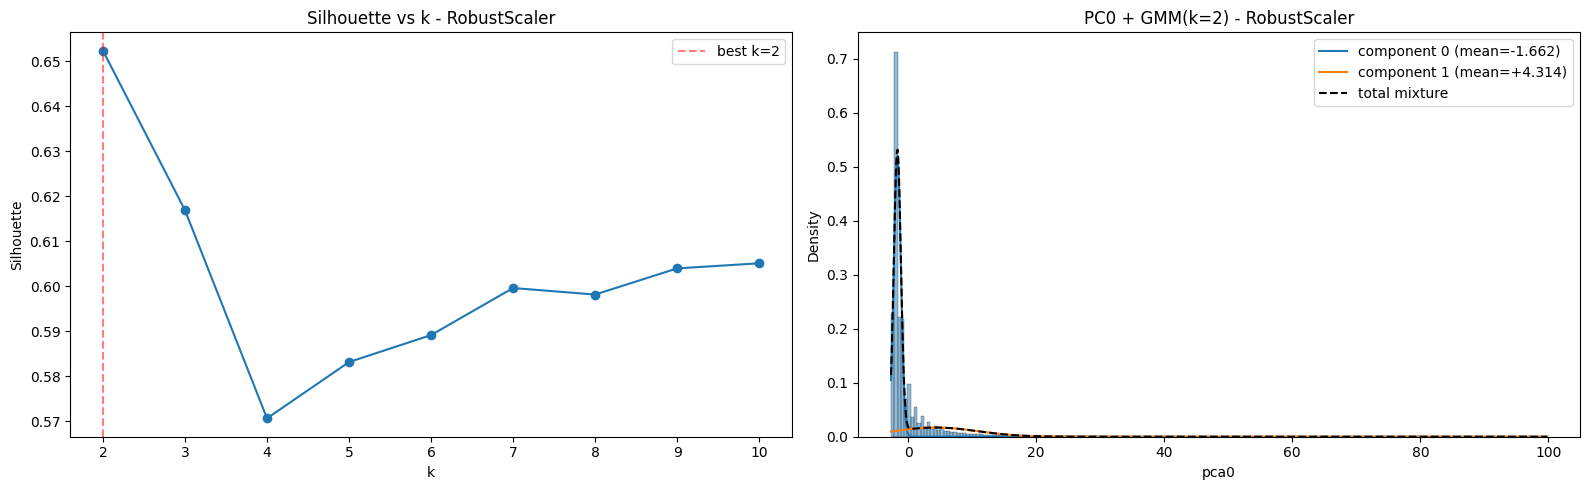

In [15]:
gmm_rob = fit_gmm_overlay(scores_rob[:, 0], ks, sil_rob, bestk_rob, "RobustScaler")

## Summary — StandardScaler vs RobustScaler vs prior results

In [16]:
print("PC0 explained variance:")
print(f"  StandardScaler : {pca_std.explained_variance_ratio_[0]*100:.2f}%")
print(f"  RobustScaler   : {pca_rob.explained_variance_ratio_[0]*100:.2f}%")
print(f"  (row-normalized original notebook: 57.83%  |  paper: 65.91%)")
print()
print("Best k (silhouette / BIC):")
print(f"  StandardScaler : {bestk_std} / {bestk_bic_std}")
print(f"  RobustScaler   : {bestk_rob} / {bestk_bic_rob}")
print()
print("Top-3 PC0 loadings:")
print(f"  StandardScaler : {list(load_std['Feature'][:3])}")
print(f"  RobustScaler   : {list(load_rob['Feature'][:3])}")

PC0 explained variance:
  StandardScaler : 43.89%
  RobustScaler   : 62.47%
  (row-normalized original notebook: 57.83%  |  paper: 65.91%)

Best k (silhouette / BIC):
  StandardScaler : 5 / 10
  RobustScaler   : 2 / 10

Top-3 PC0 loadings:
  StandardScaler : ['word_rate', 'syllable_rate', 'token_count']
  RobustScaler   : ['Repetitions In Previous Utterance', 'Repetitions In Current Utterance', 'token_count']


## Export — both scalers in one CSV (does not touch the original output)

In [17]:
for i in range(pca_std.n_components_):
    df[f"pca_std{i}"] = scores_std[:, i]
df["gmm_label_std"] = gmm_std.predict(scores_std[:, 0].reshape(-1, 1))
for i in range(pca_rob.n_components_):
    df[f"pca_rob{i}"] = scores_rob[:, i]
df["gmm_label_rob"] = gmm_rob.predict(scores_rob[:, 0].reshape(-1, 1))

output_path = "../utterances_v2/paper_aligned_standardized_PCA.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} rows x {len(df.columns)} columns to {output_path}")

Saved 212210 rows x 63 columns to ../utterances_v2/paper_aligned_standardized_PCA.csv


# Part C — Transform (winsorize + log1p) then StandardScaler

The *correct* robustness fix (unlike RobustScaler, which under-shrank the zero-inflated counts):
1. **Winsorize** every column at [1%, 99%] — tames extreme outliers like Turn Gap +66 s.
2. **log1p** the heavy-tailed, non-negative, zero-inflated features — `log1p(0)=0`, so it handles
   zero-inflation cleanly and compresses long right tails. Turn Gap is *not* logged (it has
   negatives = overlapping speech); it is winsorized only.
3. **StandardScaler**, then PCA.

Goal: keep every feature contributing (as in Part A) while preventing the few heavy-tailed counts
from regaining dominance.

### C1 — Transform & inspect skew before/after

In [18]:
from scipy.stats import skew

# Heavy-tailed, non-negative, zero-inflated features -> log1p.
# Turn Gap has negatives (overlaps), so it is winsorized only, not logged.
log_cols = [
    "token_count", "word_rate", "syllable_rate", "Pronouns per Second",
    "Repetitions In Current Utterance", "Repetitions In Previous Utterance",
    "Filler Words per Second",
]
Xt = df[feature_cols].copy()
for c in feature_cols:                       # winsorize all columns at [1%, 99%]
    lo, hi = Xt[c].quantile(0.01), Xt[c].quantile(0.99)
    Xt[c] = Xt[c].clip(lo, hi)
for c in log_cols:                           # log1p the skewed non-negative ones
    Xt[c] = np.log1p(Xt[c])

print(f"{'feature':35s} {'skew_before':>12s} {'skew_after':>12s}")
for c in feature_cols:
    print(f"{c:35s} {skew(df[c]):>12.2f} {skew(Xt[c]):>12.2f}")
X_trans = Xt.values

feature                              skew_before   skew_after
token_count                                 1.18         0.02
loudness mean                               2.18         1.59
loudness std                                2.15         1.54
loudness range                              2.08         1.55
Turn Gap                                   -0.70        -0.86
word_rate                                   0.17        -0.27
syllable_rate                               0.09        -0.40
Pronouns per Second                         0.72         0.21
Repetitions In Current Utterance            3.71         1.04
Repetitions In Previous Utterance           5.03         1.44
Filler Words per Second                     1.75         1.14


### C2 — Transformed-standardized PCA

In [19]:
X_trans_std, pca_trans, scores_trans = run_pca(X_trans, StandardScaler())
report_variance(pca_trans, "log1p+winsor+Standard")

[log1p+winsor+Standard] explained variance ratio:
[0.48755889 0.18891219 0.08856856 0.07749178 0.06611545 0.04583842
 0.02644398 0.00855294 0.00530649 0.00324595 0.00196534]
[log1p+winsor+Standard] cumulative:
[0.48755889 0.67647108 0.76503964 0.84253142 0.90864688 0.9544853
 0.98092928 0.98948222 0.99478871 0.99803466 1.        ]
[log1p+winsor+Standard] PC0 explains 48.76% of variance


### C3 — Histogram of PC0 & scree

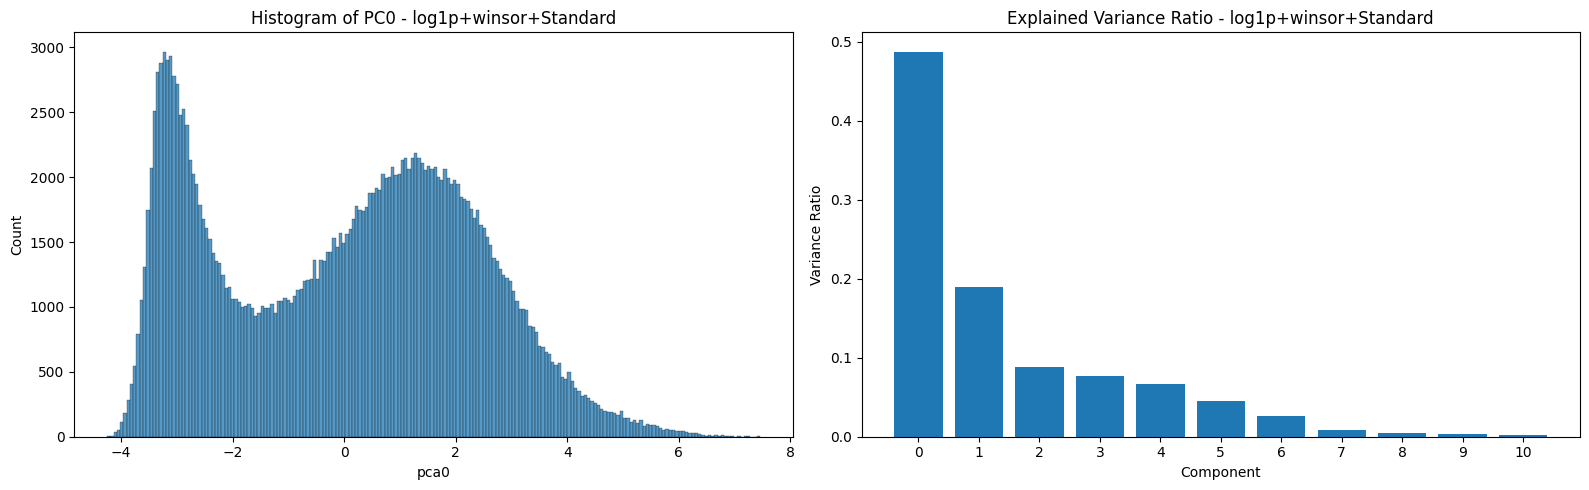

In [20]:
plot_hist_scree(scores_trans, pca_trans, "log1p+winsor+Standard")

### C4 — Table 2: feature importance to PC0

In [21]:
load_tr = loadings_table(pca_trans, feature_cols, "log1p+winsor+Standard")

Table 2 - feature importance to PC0 (log1p+winsor+Standard)

Magnitude                           Feature
  +0.3958                       token_count
  +0.3874                         word_rate
  +0.3781                     syllable_rate
  +0.3314               Pronouns per Second
  +0.3242  Repetitions In Current Utterance
  +0.3006                     loudness mean
  +0.2945                    loudness range
  +0.2584                      loudness std
  +0.2102 Repetitions In Previous Utterance
  +0.1694           Filler Words per Second
  +0.1365                          Turn Gap


### C5 — Silhouette (k=2..10) & BIC (k=1..10)

In [22]:
ks, sil_tr, bestk_tr, bics_tr, bestk_bic_tr = silhouette_bic(scores_trans[:, 0])
for k, s in zip(ks, sil_tr):
    print(f"k={k}: silhouette = {s:.4f}")
print(f"\nBest k by silhouette: {bestk_tr}")
print(f"\n{'k':>3} {'BIC':>14}")
print("-" * 20)
for k, b in zip(range(1, 11), bics_tr):
    print(f"{k:>3} {b:>14.0f}")
print(f"\nBest k by BIC: {bestk_bic_tr}")

k=2: silhouette = 0.5783
k=3: silhouette = 0.5680
k=4: silhouette = 0.5725
k=5: silhouette = 0.5649
k=6: silhouette = 0.5515
k=7: silhouette = 0.5457
k=8: silhouette = 0.5351
k=9: silhouette = 0.5395
k=10: silhouette = 0.5306

Best k by silhouette: 2

  k            BIC
--------------------
  1         958668
  2         894572
  3         895020
  4         894132
  5         892507
  6         891449
  7         890691
  8         890304
  9         890242
 10         890083

Best k by BIC: 10


### C6 — Best-k GMM fit & overlay

[log1p+winsor+Standard] GMM k=2:
  component 1: mean=-2.9257, std=0.4944, weight=0.270
  component 0: mean=+1.0799, std=1.7109, weight=0.730


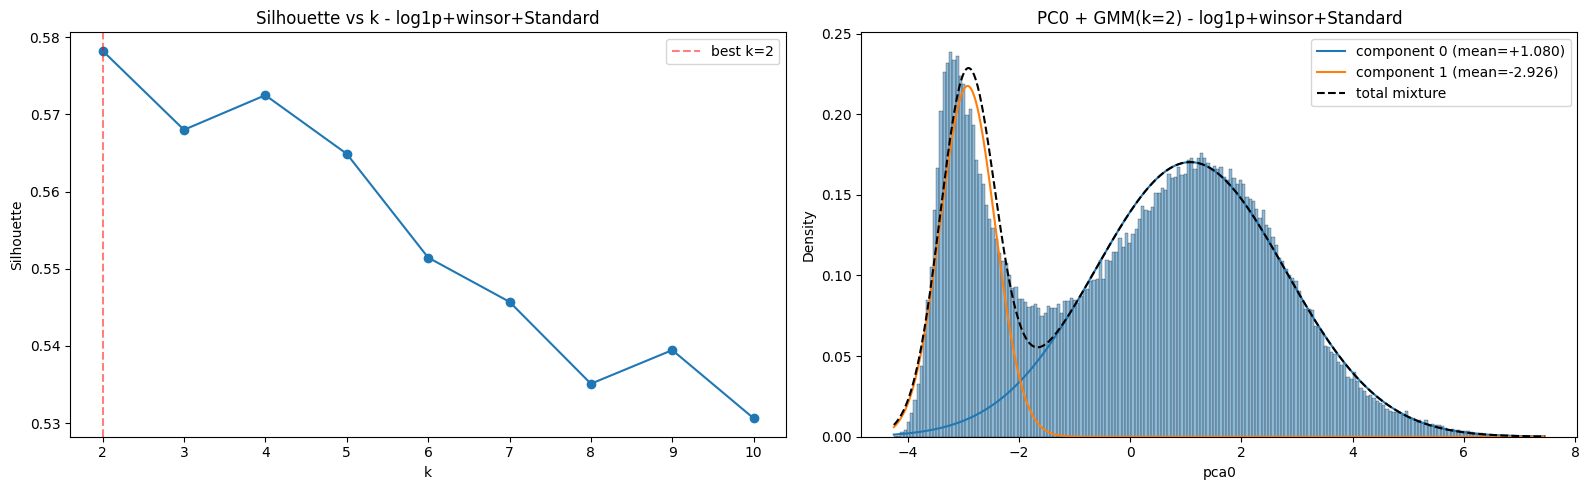

In [23]:
gmm_tr = fit_gmm_overlay(scores_trans[:, 0], ks, sil_tr, bestk_tr, "log1p+winsor+Standard")

# Part D — Is the StandardScaler k=5 real, or is GMM overfitting a smooth density?

Two clues already point to "no discrete clusters": silhouette *rose* with k (peaking at 5, not a
sharp k=2 win) and BIC kept dropping all the way to k=10. Both are hallmarks of a **smooth,
non-Gaussian unimodal** distribution that a GMM tiles into pieces — not genuine separated modes.

We test this directly on the StandardScaler PC0:
- **KDE mode count across bandwidths** — a true multimodal variable keeps >1 density peak as the
  smoothing bandwidth varies; a skewed-but-unimodal variable collapses to a single peak.
- **BIC curve shape** — a real 2-cluster variable shows a sharp BIC drop at k=2 then flattens; a
  continuous one shows monotone decrease with no elbow.
- **Overlay** of the KDE against the GMM k=2 and k=5 mixture densities — if both mixtures just retrace
  the same single smooth curve, the components are approximation artifacts, not clusters.

### D1 — KDE mode count across bandwidths + shape stats

In [24]:
from scipy.stats import gaussian_kde, kurtosis
from scipy.signal import find_peaks

pc0 = scores_std[:, 0]
print(f"PC0 (StandardScaler): skew={skew(pc0):+.3f}, excess kurtosis={kurtosis(pc0):+.3f}")

grid = np.linspace(pc0.min(), pc0.max(), 2000)
samp = pc0[::10]   # subsample (~21k) for KDE speed
print(f"\n{'bw_factor':>10s} {'n_modes':>8s}  mode_locations")
for bw in [0.15, 0.25, 0.40, 0.60]:
    dens = gaussian_kde(samp, bw_method=bw)(grid)
    peaks, _ = find_peaks(dens, prominence=dens.max() * 0.01)
    print(f"{bw:>10.2f} {len(peaks):>8d}  {np.round(grid[peaks], 2)}")

PC0 (StandardScaler): skew=+0.501, excess kurtosis=-0.122

 bw_factor  n_modes  mode_locations
      0.15        2  [-2.62  0.71]
      0.25        2  [-2.48  0.62]


      0.40        2  [-2.09  0.5 ]
      0.60        1  [-0.18]


### D2 — BIC curve shape (elbow test)

In [25]:
print("GMM on PC0 (StandardScaler) - BIC curve shape:")
print(f"{'k':>3} {'BIC':>12} {'dBIC':>10}")
prev = None
for k, b in zip(range(1, 11), bics_std):
    d = "" if prev is None else f"{b - prev:+.0f}"
    print(f"{k:>3} {b:>12.0f} {d:>10}")
    prev = b
print("\nNo elbow -> BIC keeps improving with every added component -> no natural cluster count.")

GMM on PC0 (StandardScaler) - BIC curve shape:
  k          BIC       dBIC
  1       936361           
  2       882908     -53453
  3       878066      -4842
  4       877647       -419
  5       876724       -923
  6       875547      -1177
  7       874866       -681
  8       873857      -1009
  9       873620       -236
 10       873581        -39

No elbow -> BIC keeps improving with every added component -> no natural cluster count.


### D3 — KDE vs GMM(k=2) vs GMM(k=5) overlay

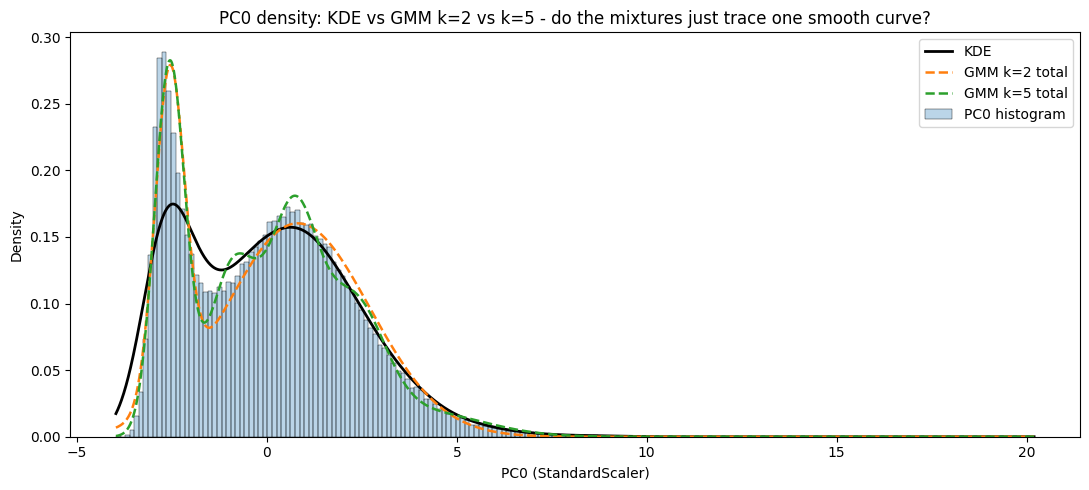

In [26]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(pc0, bins=200, stat="density", alpha=0.3, ax=ax, label="PC0 histogram")
ax.plot(grid, gaussian_kde(samp, bw_method=0.25)(grid), "k-", lw=2, label="KDE")
for kk, color in [(2, "C1"), (5, "C2")]:
    g = GaussianMixture(n_components=kk, random_state=0).fit(pc0.reshape(-1, 1))
    m = g.means_.flatten(); s = np.sqrt(g.covariances_.flatten()); w = g.weights_
    tot = np.zeros_like(grid)
    for i in range(kk):
        tot += w[i] * (1 / (s[i] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((grid - m[i]) / s[i]) ** 2)
    ax.plot(grid, tot, "--", color=color, lw=1.8, label=f"GMM k={kk} total")
ax.set_xlabel("PC0 (StandardScaler)")
ax.set_title("PC0 density: KDE vs GMM k=2 vs k=5 - do the mixtures just trace one smooth curve?")
ax.legend()
plt.tight_layout(); plt.show()

## Final export — add transformed-PCA columns to the CSV

In [27]:
for i in range(pca_trans.n_components_):
    df[f"pca_tr{i}"] = scores_trans[:, i]
df["gmm_label_tr"] = gmm_tr.predict(scores_trans[:, 0].reshape(-1, 1))
df.to_csv("../utterances_v2/paper_aligned_standardized_PCA.csv", index=False)
print(f"Re-saved with transformed columns: {df.shape[0]} rows x {df.shape[1]} columns")

Re-saved with transformed columns: 212210 rows x 75 columns


# Part E — Diagnose the GMM clusters, then strip backchannels

Parts A–D gave a clean bimodal PC0 and silhouette-best k=2 under the transformed pipeline — which
looked like strong support for two conversational styles. Before believing it, we ask: **what
actually populates the two GMM clusters?** Then we test whether the bimodality is a real style split
or an artifact of minimal "listening-noise" utterances (yeah / uh-huh / um-hum …).

### E1 — What is in each `gmm_label_tr` cluster?

In [28]:
lab = "gmm_label_tr"
m = df.groupby(lab)["word_rate"].mean()
HI, HC = m.idxmax(), m.idxmin()           # higher intensity (word_rate) = High Involvement
hc, hi = df[df[lab] == HC], df[df[lab] == HI]
print(f"low-intensity cluster  (label {HC}): n={len(hc):>7d}, mean token_count={hc['token_count'].mean():.2f}, "
      f"share <=2 tokens={(hc['token_count'] <= 2).mean() * 100:.1f}%")
print(f"high-intensity cluster (label {HI}): n={len(hi):>7d}, mean token_count={hi['token_count'].mean():.2f}, "
      f"share <=2 tokens={(hi['token_count'] <= 2).mean() * 100:.1f}%")
print()
print("Top 15 transcripts in the low-intensity (\"HC\") cluster:")
print(hc["Transcript"].astype(str).str.strip().str.lower().value_counts().head(15).to_string())

low-intensity cluster  (label 1): n=  59784, mean token_count=1.17, share <=2 tokens=98.0%
high-intensity cluster (label 0): n= 152426, mean token_count=16.71, share <=2 tokens=7.9%

Top 15 transcripts in the low-intensity ("HC") cluster:
Transcript
yeah         11892
um-hum       10509
uh-huh        9959
right         3819
oh            1984
um            1434
uh             910
yes            909
okay           672
huh            658
so             603
oh yeah        563
hm             552
yeah yeah      490
hum            457


The low-intensity "HC" cluster is ~98% one/two-token utterances dominated by `yeah / um-hum /
uh-huh / right / oh`. It is **backchannels vs. real speech**, not High Considerateness vs. High
Involvement. Note also the downstream Welch t-tests are **circular (double-dipping)**: we cluster on
PC0 (≈ the sum of these 11 features) and then t-test those same features, so large Cohen's d are
guaranteed and not evidence of a style.

### E2 — Strip pure-backchannel utterances

In [29]:
import string

# An utterance is a backchannel if EVERY token is an affirmation/filler (catches "oh yeah",
# "yeah yeah", "uh-huh uh-huh" too, which a pure length cut would miss).
BC = {"yeah", "yea", "yep", "yup", "yes", "ya", "yah", "uh-huh", "uhhuh", "huh-uh", "um-hum",
      "umhum", "mm-hmm", "mm-hm", "mmhm", "mhm", "m-hm", "mm", "mmm", "hm", "hmm", "hmmm",
      "hum", "huh", "uh", "um", "er", "erm", "ah", "oh", "ooh", "aw", "okay", "ok", "right",
      "sure", "wow", "gosh"}

def is_backchannel(t):
    toks = [w.strip(string.punctuation).lower() for w in str(t).split()]
    toks = [w for w in toks if w]
    return len(toks) > 0 and all(w in BC for w in toks)

df["is_backchannel"] = df["Transcript"].apply(is_backchannel)
print(f"Backchannel utterances: {df['is_backchannel'].sum()} ({df['is_backchannel'].mean() * 100:.1f}%)")
print(f"Remaining (substantive): {(~df['is_backchannel']).sum()}")
print()
print("SANITY - short (<=2 tok) utterances we KEEP (should be real content):")
kept = df[~df["is_backchannel"] & (df["token_count"] <= 2)]
print(kept["Transcript"].astype(str).str.strip().str.lower().value_counts().head(12).to_string())

sub = df[~df["is_backchannel"]].reset_index(drop=True)

Backchannel utterances: 53570 (25.2%)
Remaining (substantive): 158640

SANITY - short (<=2 tok) utterances we KEEP (should be real content):
Transcript
so                 644
oh really          564
well               505
and uh             458
that's right       435
no                 420
really             394
and                377
but                365
but uh             312
yeah [laughter]    247
you know           226


### E3 — Re-run the corrected pipeline on substantive utterances only

In [30]:
Xt_sub = sub[feature_cols].copy()
for c in feature_cols:
    lo, hi_ = Xt_sub[c].quantile(0.01), Xt_sub[c].quantile(0.99)
    Xt_sub[c] = Xt_sub[c].clip(lo, hi_)
for c in log_cols:
    Xt_sub[c] = np.log1p(Xt_sub[c])

X_sub_std, pca_sub, scores_sub = run_pca(Xt_sub.values, StandardScaler())
report_variance(pca_sub, "substantive (backchannels removed)")
load_sub = loadings_table(pca_sub, feature_cols, "substantive")

[substantive (backchannels removed)] explained variance ratio:
[0.38407695 0.22895926 0.09943119 0.08864054 0.07486418 0.05602522
 0.04253671 0.01044158 0.00794268 0.0051933  0.00188839]
[substantive (backchannels removed)] cumulative:
[0.38407695 0.61303621 0.7124674  0.80110794 0.87597212 0.93199734
 0.97453405 0.98497563 0.99291831 0.99811161 1.        ]
[substantive (backchannels removed)] PC0 explains 38.41% of variance
Table 2 - feature importance to PC0 (substantive)

Magnitude                           Feature
  +0.4300                       token_count
  +0.4156                         word_rate
  +0.4037                     syllable_rate
  +0.3618  Repetitions In Current Utterance
  +0.2901               Pronouns per Second
  +0.2807                     loudness mean
  +0.2703                    loudness range
  +0.2293                      loudness std
  +0.1894 Repetitions In Previous Utterance
  +0.1161                          Turn Gap
  +0.1026           Filler Words per

### E4 — Is it still bimodal?  (histogram, KDE modes, silhouette/BIC, forced-k=2 length check)

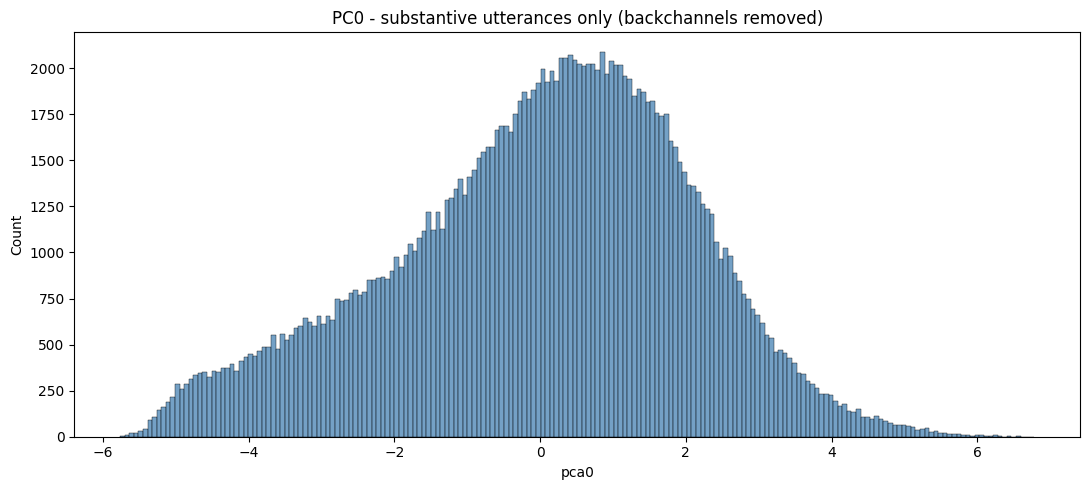

PC0 skew = -0.315


  KDE bw=0.15: 1 mode(s) at [0.58]
  KDE bw=0.25: 1 mode(s) at [0.61]


  KDE bw=0.4: 1 mode(s) at [0.56]


  KDE bw=0.6: 1 mode(s) at [0.46]


silhouette: {2: 0.577, 3: 0.538, 4: 0.524, 5: 0.522, 6: 0.525, 7: 0.522, 8: 0.517, 9: 0.52, 10: 0.517} -> best k = 2

Forced k=2 -> token_count per cluster (length check):
  cluster 0: n=  50332, token_count median=3, mean=4.4
  cluster 1: n= 108308, token_count median=19, mean=21.6


In [31]:
from scipy.stats import gaussian_kde, skew
from scipy.signal import find_peaks

pc0s = scores_sub[:, 0]
plt.figure(figsize=(11, 5))
sns.histplot(pc0s, bins=200, color="steelblue")
plt.title("PC0 - substantive utterances only (backchannels removed)")
plt.xlabel("pca0"); plt.tight_layout(); plt.show()

print(f"PC0 skew = {skew(pc0s):+.3f}")
grid = np.linspace(pc0s.min(), pc0s.max(), 2000); samp = pc0s[::8]
for bw in [0.15, 0.25, 0.40, 0.60]:
    d = gaussian_kde(samp, bw_method=bw)(grid)
    pk, _ = find_peaks(d, prominence=d.max() * 0.01)
    print(f"  KDE bw={bw}: {len(pk)} mode(s) at {np.round(grid[pk], 2)}")

ks_s, sil_s, bk_s, bic_s, bkb_s = silhouette_bic(pc0s)
print("silhouette:", {k: round(s, 3) for k, s in zip(ks_s, sil_s)}, "-> best k =", bk_s)

# Even if forced to k=2, is the split just utterance length?
g2 = GaussianMixture(n_components=2, random_state=0).fit(pc0s.reshape(-1, 1))
sub2 = sub.copy(); sub2["lab"] = g2.predict(pc0s.reshape(-1, 1))
print("\nForced k=2 -> token_count per cluster (length check):")
for L in sub2.groupby("lab")["word_rate"].mean().sort_values().index:
    gg = sub2[sub2["lab"] == L]
    print(f"  cluster {L}: n={len(gg):>7d}, token_count median={gg['token_count'].median():.0f}, mean={gg['token_count'].mean():.1f}")

### E5 — Conclusion

Once backchannels are removed, **PC0 is unimodal** (KDE = 1 mode at every bandwidth; skew collapses
toward 0; single-hump histogram). Silhouette may still report k=2, but that is GMM over-segmenting a
single smooth hump (the Part-D trap), and forcing k=2 only separates **short vs. long** substantive
utterances — length, not style.

**The bimodal "two conversational styles" finding is an artifact of backchannel utterances.** The
underlying style dimension is *continuous*, which is consistent with Tannen's description of a
*continuum between two poles* — but the discrete two-cluster (2-Gaussian) claim does not survive.
A conversational style is a property of a *speaker*, not a one-word utterance, so the real test of
HC/HI is a **speaker-level** analysis (see the speaker-level notebook).